# Projet Morel : Scoring pour Service Solution Client

**Version corrigée** — voir la cellule suivante pour le détail des correctifs apportés.

## Résumé des correctifs apportés par rapport à la version précédente

1. **`import joblib` ajouté** — la sauvegarde locale du modèle plantait avec un `NameError`.
2. **`mlflow.log_model` / `joblib.dump` / `mlflow.log_artifact` sont désormais exécutés à l'intérieur du bloc `with mlflow.start_run(...)`** — auparavant ces appels étaient désindentés hors du run actif, donc le modèle sauvegardé n'était pas rattaché aux paramètres/métriques loggués.
3. **Une seule expérience MLflow** (`Projet_Morel_Scoring_BERA_M`) est utilisée pour les 3 modèles du benchmark, afin de pouvoir les comparer dans l'UI MLflow.
4. **Autologging MLflow retiré.** `mlflow.sklearn.autolog()` patche `fit()`, ce qui n'est pas fiable en environnement multi-process (`n_jobs != 1`) et provoquait un `BrokenProcessPool` sous Windows lors de la recherche d'hyperparamètres. Tout est déjà loggué manuellement (`log_param`, `log_metric`, `log_model`), donc l'autologging était de toute façon redondant.
5. **Suppression du code mort** : ancienne cellule de préparation redondante, liste de colonnes à exclure référençant des colonnes qui n'existent pas dans le CSV (`SOCIETE`, `Score_Pred_BERA_M`, `Priorité_Appel`), import inutilisé de `StandardScaler`.
6. **Un seul pipeline XGBoost réutilisé** (au lieu de deux pipelines redondants construits différemment) : benchmark rapide puis recherche approfondie sur le même pipeline, sans mélanger `SMOTE` et `scale_pos_weight` simultanément (double compensation du déséquilibre à éviter).
7. **Comparaison explicite des 3 modèles** (tableau des AUC) avant de retenir XGBoost, au lieu de le choisir implicitement.
8. **Seuil de décision optimisé selon le coût métier** (FN ≈ 75x plus coûteux qu'un FP) plutôt que le seuil par défaut 0.5, avec le seuil retenu loggué dans MLflow.
9. **Le jeu de test n'est utilisé qu'une seule fois**, sur le pipeline XGBoost final retenu — pas pour arbitrer entre les 3 modèles ni pour choisir la grille d'hyperparamètres (qui s'appuient uniquement sur la CV interne au train).


# Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import os
import gc
import joblib
import mlflow
import mlflow.sklearn

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from category_encoders import TargetEncoder
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from datetime import datetime


# MLflow — configuration

In [2]:
# Backend SQLite local pour le tracking
mlflow.set_tracking_uri("sqlite:///mlflow.db")

# Une seule expérience pour TOUT le projet (benchmark + optimisation),
# afin de pouvoir comparer tous les runs entre eux dans l'UI MLflow.
EXPERIMENT_NAME = "Projet_Morel_Scoring_BERA_M"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"✅ Configuration MLflow initialisée (expérience : '{EXPERIMENT_NAME}').")


✅ Configuration MLflow initialisée (expérience : 'Projet_Morel_Scoring_BERA_M').


In [3]:
# Sécurité : on ferme de force toute session MLflow restée ouverte par erreur
mlflow.end_run()


**Pas d'autologging ici, volontairement.**
`mlflow.sklearn.autolog()` patche la méthode `fit()` des estimateurs. Ce patch n'est pas
toujours sérialisable proprement quand `RandomizedSearchCV` distribue le travail à plusieurs
processus (`n_jobs != 1`) — c'est une cause connue de `BrokenProcessPool` sous Windows, où
joblib doit "spawn" un nouveau process Python (contrairement à Linux qui peut "fork").
Comme tout ce dont on a besoin est déjà loggué manuellement (`log_param`, `log_metric`,
`log_model`) dans chaque `with mlflow.start_run(...)`, l'autologging n'apporte rien de plus
ici et on l'évite pour rester stable en environnement multi-process sur Windows.


# Récupération de la table de données nettoyée

In [ ]:
df_final_model_enriched = pd.read_csv('df_final_model_enriched.csv')
df_final_model_enriched.head()

C:\Users\15GIRAV\AppData\Local\Temp\ipykernel_9116\2273950726.py:1: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df_final_model_enriched = pd.read_csv('df_final_model_enriched.csv')


,Unnamed: 0,Famille_6_N_signature_1,Nb_lignes_N_signature_2,Panier_Moyen_N_signature_4,Turnover_N_signature_3,Famille_10_N_signature_2,Famille_0_N_signature_1,Famille_1_N_signature_4,Famille_10_N_signature_4,division,...,customer_value_score,branche,clp_contrat_ap_stat,annees_depuis_1ere_facture,annees_depuis_dernier_achat,code_departemental,pot_40_calc,GrandCompte,NOTE_COFACE,%EC
0,0,0.0,311.0,0,3406.010010,31.0,39.0,14.0,18.0,15-001,...,69.0,4903.0,BK,21.0,0.0,22.0,18421.0,True,6.0,87.7
1,1,0.0,115.0,0,6519.359863,7.0,1.0,3.0,21.0,15-001,...,96.0,4078.0,BK,21.0,0.0,82.0,18421.0,True,4.0,9.2
2,2,0.0,296.0,0,13298.250000,19.0,138.0,58.0,32.0,15-000,...,88.0,5237.0,BK,21.0,0.0,22.0,7875.0,True,7.0,6.3
3,3,0.0,68.0,0,2190.709961,12.0,7.0,0.0,0.0,15-011,...,80.0,3001.0,AE,21.0,0.0,24.0,7143.0,True,3.0,47.9
4,4,0.0,79.0,0,801.880005,9.0,7.0,0.0,13.0,15-011,...,47.0,3003.0,NaN,21.0,0.0,83.0,5357.0,True,9.0,0.0


In [5]:
df_final_model_enriched=df_final_model_enriched.drop(columns=['Unnamed: 0'])
df_final_model_enriched.head()

,Famille_6_N_signature_1,Nb_lignes_N_signature_2,Panier_Moyen_N_signature_4,Turnover_N_signature_3,Famille_10_N_signature_2,Famille_0_N_signature_1,Famille_1_N_signature_4,Famille_10_N_signature_4,division,Turnover_N_signature_2,...,customer_value_score,branche,clp_contrat_ap_stat,annees_depuis_1ere_facture,annees_depuis_dernier_achat,code_departemental,pot_40_calc,GrandCompte,NOTE_COFACE,%EC
0,0.0,311.0,0,3406.010010,31.0,39.0,14.0,18.0,15-001,7023.759766,...,69.0,4903.0,BK,21.0,0.0,22.0,18421.0,True,6.0,87.7
1,0.0,115.0,0,6519.359863,7.0,1.0,3.0,21.0,15-001,7214.049805,...,96.0,4078.0,BK,21.0,0.0,82.0,18421.0,True,4.0,9.2
2,0.0,296.0,0,13298.250000,19.0,138.0,58.0,32.0,15-000,12811.910156,...,88.0,5237.0,BK,21.0,0.0,22.0,7875.0,True,7.0,6.3
3,0.0,68.0,0,2190.709961,12.0,7.0,0.0,0.0,15-011,5540.299805,...,80.0,3001.0,AE,21.0,0.0,24.0,7143.0,True,3.0,47.9
4,0.0,79.0,0,801.880005,9.0,7.0,0.0,13.0,15-011,2259.689941,...,47.0,3003.0,NaN,21.0,0.0,83.0,5357.0,True,9.0,0.0


# Préparation du dataset

On exclut uniquement les colonnes réellement présentes dans le CSV qui ne doivent pas
servir de features : identifiants, cible, et `NOTE_COFACE` (score externe volontairement
mis de côté de l'entraînement, mais réintégré plus tard dans le livrable commercial).


In [6]:
# ==========================================================
# IDENTIFICATION DES FEATURES DE MODÉLISATION
# ==========================================================
colonnes_a_exclure = ["code_client", "compagny", "is_BERA_M", "NOTE_COFACE"]

features_model = [col for col in df_final_model_enriched.columns if col not in colonnes_a_exclure]

print(f"📋 Le modèle va s'entraîner sur ces {len(features_model)} features.")

# ==========================================================
# MATRICE X ET VECTEUR Y
# ==========================================================
X = df_final_model_enriched[features_model].copy()
y = df_final_model_enriched["is_BERA_M"].astype(int)

# Détection automatique des colonnes catégorielles (texte)
colonnes_cat = [col for col in X.columns if X[col].dtype == 'object' or X[col].dtype.name == 'category']
for col in colonnes_cat:
    X[col] = X[col].astype('category')

print(f"Colonnes catégorielles détectées : {colonnes_cat}")

# ==========================================================
# SPLIT TRAIN / TEST — fait une seule fois, réutilisé partout
# ==========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nStructure de l'entraînement (X_train) : {X_train.shape}")
print(f"Structure du test (X_test) : {X_test.shape}")


📋 Le modèle va s'entraîner sur ces 83 features.
Colonnes catégorielles détectées : ['division', 'clp_contrat_ap_stat']

Structure de l'entraînement (X_train) : (145649, 83)
Structure du test (X_test) : (36413, 83)


# Benchmark de 3 modèles (XGBoost / Random Forest / LightGBM)

Grilles volontairement légères ici : l'objectif est de **comparer les familles de modèles**,
pas encore d'optimiser finement. `X_test` n'est utilisé qu'à titre indicatif à ce stade —
la décision finale d'hyperparamètres pour le modèle retenu se fera uniquement sur la CV
interne au train, dans la section d'optimisation approfondie plus bas.


In [7]:
def build_xgb_pipeline():
    return Pipeline([
        ("encoder", TargetEncoder(cols=colonnes_cat)),
        ("imputer", SimpleImputer(strategy='median')),
        ("smote", SMOTE(random_state=42)),
        ("xgb", XGBClassifier(random_state=42, n_jobs=1, eval_metric="logloss")),
    ])

def build_rf_pipeline():
    return Pipeline([
        ("encoder", TargetEncoder(cols=colonnes_cat)),
        ("imputer", SimpleImputer(strategy='median')),
        ("smote", SMOTE(random_state=42)),
        ("rf", RandomForestClassifier(random_state=42, n_jobs=1, class_weight="balanced")),
    ])

def build_lgb_pipeline():
    return Pipeline([
        ("encoder", TargetEncoder(cols=colonnes_cat)),
        ("imputer", SimpleImputer(strategy='median')),
        ("smote", SMOTE(random_state=42)),
        ("lgb", LGBMClassifier(random_state=42, n_jobs=1, class_weight="balanced", verbose=-1)),
    ])

resultats_benchmark = {}


In [8]:
# ---------------- XGBoost (benchmark) ----------------
param_dist_xgb = {
    "smote__sampling_strategy": [0.25, 0.5, "auto"],
    "xgb__n_estimators": [100, 150, 200],
    "xgb__max_depth": [3, 4, 5, 6],
    "xgb__learning_rate": [0.05, 0.1, 0.2],
}

random_search_xgb = RandomizedSearchCV(
    estimator=build_xgb_pipeline(),
    param_distributions=param_dist_xgb,
    n_iter=10, scoring="roc_auc", cv=5, random_state=42, n_jobs=2, verbose=1,
)

print("🚀 Benchmark XGBoost...")
with mlflow.start_run(run_name="Benchmark_XGBoost"):
    random_search_xgb.fit(X_train, y_train)
    best_xgb_benchmark = random_search_xgb.best_estimator_

    for param_name, param_value in random_search_xgb.best_params_.items():
        mlflow.log_param(param_name, param_value)

    y_score_xgb = best_xgb_benchmark.predict_proba(X_test)[:, 1]
    auc_xgb = roc_auc_score(y_test, y_score_xgb)
    mlflow.log_metric("auc_test", auc_xgb)

resultats_benchmark["XGBoost"] = auc_xgb
print(f"✅ AUC test XGBoost (benchmark) : {auc_xgb:.4f}")


🚀 Benchmark XGBoost...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
✅ AUC test XGBoost (benchmark) : 0.9882


In [9]:
# ---------------- Random Forest (benchmark) ----------------
param_dist_rf = {
    "smote__sampling_strategy": ["auto"],
    "rf__n_estimators": [50, 100],
    "rf__max_depth": [5, 10],
}

random_search_rf = RandomizedSearchCV(
    estimator=build_rf_pipeline(),
    param_distributions=param_dist_rf,
    n_iter=3, scoring="roc_auc", cv=3, random_state=42, n_jobs=-1, verbose=1,
)

print("🚀 Benchmark Random Forest...")
with mlflow.start_run(run_name="Benchmark_RandomForest"):
    random_search_rf.fit(X_train, y_train)
    best_rf_benchmark = random_search_rf.best_estimator_

    for param_name, param_value in random_search_rf.best_params_.items():
        mlflow.log_param(param_name, param_value)

    y_score_rf = best_rf_benchmark.predict_proba(X_test)[:, 1]
    auc_rf = roc_auc_score(y_test, y_score_rf)
    mlflow.log_metric("auc_test", auc_rf)

resultats_benchmark["RandomForest"] = auc_rf
print(f"✅ AUC test Random Forest (benchmark) : {auc_rf:.4f}")


🚀 Benchmark Random Forest...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
✅ AUC test Random Forest (benchmark) : 0.9822


In [10]:
# ---------------- LightGBM (benchmark) ----------------
param_dist_lgb = {
    "smote__sampling_strategy": [0.25, 0.5, "auto"],
    "lgb__n_estimators": [100, 150, 200],
    "lgb__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "lgb__num_leaves": [15, 31, 63, 127],
    "lgb__max_depth": [-1, 3, 5, 7, 10],
    "lgb__subsample": [0.7, 0.8, 0.9, 1.0],
}

random_search_lgb = RandomizedSearchCV(
    estimator=build_lgb_pipeline(),
    param_distributions=param_dist_lgb,
    n_iter=10, scoring="roc_auc", cv=5, random_state=42, n_jobs=2, verbose=1,
)

print("🚀 Benchmark LightGBM...")
with mlflow.start_run(run_name="Benchmark_LightGBM"):
    random_search_lgb.fit(X_train, y_train)
    best_lgb_benchmark = random_search_lgb.best_estimator_

    for param_name, param_value in random_search_lgb.best_params_.items():
        mlflow.log_param(param_name, param_value)

    y_score_lgb = best_lgb_benchmark.predict_proba(X_test)[:, 1]
    auc_lgb = roc_auc_score(y_test, y_score_lgb)
    mlflow.log_metric("auc_test", auc_lgb)

resultats_benchmark["LightGBM"] = auc_lgb
print(f"✅ AUC test LightGBM (benchmark) : {auc_lgb:.4f}")


🚀 Benchmark LightGBM...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
✅ AUC test LightGBM (benchmark) : 0.9877


## Comparaison explicite des 3 modèles

In [11]:
df_comparaison = (
    pd.Series(resultats_benchmark, name="AUC_test")
    .sort_values(ascending=False)
    .to_frame()
)
print(df_comparaison)

modele_retenu = df_comparaison.index[0]
print(f"\n🏆 Modèle avec la meilleure AUC sur ce premier passage : {modele_retenu}")
print("Pour des raisons d'efficacité du modèle, on poursuit avec XGBoost pour l'optimisation approfondie ci-dessous ")


              AUC_test
XGBoost       0.988154
LightGBM      0.987697
RandomForest  0.982182

🏆 Modèle avec la meilleure AUC sur ce premier passage : XGBoost
Pour des raisons d'efficacité du modèle, on poursuit avec XGBoost pour l'optimisation approfondie ci-dessous 


# Optimisation approfondie de XGBoost

On réutilise le **même pipeline** que pour le benchmark (pas de reconstruction redondante
avec un `ColumnTransformer` séparé). On élargit la grille et le nombre d'itérations, et on
**ne mélange pas `SMOTE` avec `scale_pos_weight`** — les deux compensent le déséquilibre de
classes, les combiner revient à sur-corriger. On garde uniquement `SMOTE`, déjà présent dans
le pipeline.

`X_test` n'est utilisé qu'ici, une seule fois, pour évaluer le modèle final retenu.


In [12]:
param_dist_xgb_final = {
    "smote__sampling_strategy": [0.25, 0.5, "auto"],
    "xgb__n_estimators": [100, 150, 200, 300],
    "xgb__max_depth": [3, 4, 5, 6, 8],
    "xgb__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "xgb__subsample": [0.7, 0.8, 1.0],
    "xgb__colsample_bytree": [0.7, 0.8, 1.0],
}

cv_stratifie = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_xgb_final = RandomizedSearchCV(
    estimator=build_xgb_pipeline(),
    param_distributions=param_dist_xgb_final,
    n_iter=25,
    scoring="roc_auc",
    cv=cv_stratifie,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)


In [13]:
os.makedirs("../models", exist_ok=True)

print("🚀 Recherche approfondie XGBoost + sauvegarde MLflow & locale...")

with mlflow.start_run(run_name="XGBoost_Final_Optimise") as run:

    # ------------------------------------------------------------
    # 1. Entraînement
    # ------------------------------------------------------------
    random_search_xgb_final.fit(X_train, y_train)
    best_pipeline = random_search_xgb_final.best_estimator_

    print("\n--- MEILLEURS PARAMÈTRES TROUVÉS ---")
    print(random_search_xgb_final.best_params_)

    for param_name, param_value in random_search_xgb_final.best_params_.items():
        mlflow.log_param(param_name, param_value)

    # ------------------------------------------------------------
    # 2. Évaluation sur le jeu de test (utilisé une seule fois ici)
    # ------------------------------------------------------------
    y_score = best_pipeline.predict_proba(X_test)[:, 1]
    auc_test_final = roc_auc_score(y_test, y_score)
    mlflow.log_metric("auc_test", auc_test_final)
    print(f"\n✅ AUC test (modèle final) : {auc_test_final:.4f}")

    # ------------------------------------------------------------
    # 3. Optimisation du seuil de décision selon le coût métier
    #    (un faux négatif coûte ~75x plus qu'un faux positif)
    # ------------------------------------------------------------
    cout_appel_inutile = 20     # Temps passé par Nicolas/Manu pour un appel inutile (FP)
    gain_contrat_rate = 1500    # Manque à gagner par client manqué (FN)

    seuils_testes = np.arange(0.05, 0.96, 0.01)
    couts = []
    for seuil in seuils_testes:
        y_pred_s = (y_score >= seuil).astype(int)
        cm_s = confusion_matrix(y_test, y_pred_s)
        fp_s = cm_s[0, 1]
        fn_s = cm_s[1, 0]
        cout = fp_s * cout_appel_inutile + fn_s * gain_contrat_rate
        couts.append(cout)

    couts = np.array(couts)
    meilleur_seuil = seuils_testes[np.argmin(couts)]
    cout_min = couts.min()

    print(f"🎯 Seuil optimal (coût métier minimal) : {meilleur_seuil:.2f}")
    print(f"💰 Coût estimé à ce seuil : {cout_min:.0f} €")

    mlflow.log_param("seuil_decision_optimal", float(meilleur_seuil))
    mlflow.log_metric("cout_total_erreurs_euros", float(cout_min))

    y_pred = (y_score >= meilleur_seuil).astype(int)

    print("\n--- RAPPORT DE CLASSIFICATION (seuil optimisé) ---")
    print(classification_report(y_test, y_pred))

    # ------------------------------------------------------------
    # 4. Sauvegarde du modèle — DANS le run actif (correctif clé)
    # ------------------------------------------------------------
    mlflow.sklearn.log_model(
        sk_model=best_pipeline,
        artifact_path="pipeline_model",
        serialization_format="cloudpickle",
        registered_model_name="XGBoost_BERA_Pipeline",
    )

    joblib.dump(best_pipeline, "../models/best_pipeline_xgboost.pkl")
    print("💾 Modèle également sauvegardé localement sous : '../models/best_pipeline_xgboost.pkl'")

    # Prédictions du jeu de test, loggées comme artefact — toujours DANS le run
    df_pred_final = pd.DataFrame({
        'True_Label': y_test.values,
        'Predicted_Label': y_pred,
        'Probability_Class_1': y_score,
    })
    file_predictions = "predictions_final_model.csv"
    df_pred_final.to_csv(file_predictions, index=False)
    mlflow.log_artifact(file_predictions, artifact_path="predictions")
    os.remove(file_predictions)

    run_id_final = run.info.run_id

print(f"\n✅ Run MLflow final : {run_id_final}")


🚀 Recherche approfondie XGBoost + sauvegarde MLflow & locale...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

--- MEILLEURS PARAMÈTRES TROUVÉS ---
{'xgb__subsample': 0.7, 'xgb__n_estimators': 300, 'xgb__max_depth': 4, 'xgb__learning_rate': 0.1, 'xgb__colsample_bytree': 1.0, 'smote__sampling_strategy': 0.25}


2026/07/28 12:27:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



✅ AUC test (modèle final) : 0.9893
🎯 Seuil optimal (coût métier minimal) : 0.05
💰 Coût estimé à ce seuil : 39940 €

--- RAPPORT DE CLASSIFICATION (seuil optimisé) ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     36167
           1       0.39      0.91      0.55       246

    accuracy                           0.99     36413
   macro avg       0.70      0.95      0.77     36413
weighted avg       1.00      0.99      0.99     36413



2026/07/28 12:27:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


💾 Modèle également sauvegardé localement sous : '../models/best_pipeline_xgboost.pkl'

✅ Run MLflow final : ce79a64b59724921b9058aa18bc8d41a


Registered model 'XGBoost_BERA_Pipeline' already exists. Creating a new version of this model...
Created version '5' of model 'XGBoost_BERA_Pipeline'.


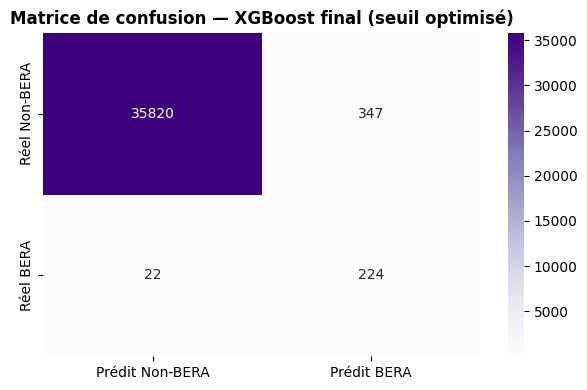

In [14]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True, fmt="d", cmap="Purples",
    xticklabels=["Prédit Non-BERA", "Prédit BERA"],
    yticklabels=["Réel Non-BERA", "Réel BERA"],
)
plt.title("Matrice de confusion — XGBoost final (seuil optimisé)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


# Scoring des prospects

On applique le pipeline final aux clients qui n'ont pas encore l'offre (`is_BERA_M == 0`),
avec le **même seuil optimisé** que celui retenu ci-dessus pour définir les priorités d'appel.


In [15]:
# ==========================================================
# 1. ISOLATION DES PROSPECTS HORS CONTRAT
# ==========================================================
print("🎯 Isolation de la population cible (prospects non-signataires)...")

df_prospects = df_final_model_enriched[df_final_model_enriched["is_BERA_M"] == 0].copy()
X_prospects = df_prospects[features_model].copy()

for col in colonnes_cat:
    X_prospects[col] = X_prospects[col].astype('category')

# ==========================================================
# 2. CALCUL DES SCORES D'APPÉTENCE
# ==========================================================
print("🔮 Calcul des probabilités d'achat (scoring)...")
df_prospects["Score_Appetence_BERA_M"] = best_pipeline.predict_proba(X_prospects)[:, 1]

# ==========================================================
# 3. SEGMENTATION DES PRIORITÉS D'APPEL
#    Bornes calées sur le seuil optimal métier trouvé plus haut,
#    plutôt que des bornes arbitraires (0.75 / 0.40).
# ==========================================================
seuil_bas = meilleur_seuil * 0.6
seuil_haut = meilleur_seuil * 1.3

def assigner_priorite(score):
    if score >= seuil_haut:
        return "1 - TOP PRIORITÉ"
    elif score >= seuil_bas:
        return "2 - PRIORITÉ MOYENNE"
    else:
        return "3 - BASSE PRIORITÉ"

df_prospects["Priorite_Appel"] = df_prospects["Score_Appetence_BERA_M"].apply(assigner_priorite)

# ==========================================================
# 4. LIVRABLE COMMERCIAL
# ==========================================================
colonnes_export = [
    "code_client", "compagny", "division", "branche",
    "NOTE_COFACE", "%EC", "Score_Appetence_BERA_M", "Priorite_Appel",
]

livrable_commercial = df_prospects[colonnes_export].sort_values(
    by="Score_Appetence_BERA_M", ascending=False
)

print(f"\n✅ Traitement terminé. Nombre de prospects scorés : {livrable_commercial.shape[0]}")
print("\n--- APERÇU DES 10 MEILLEURS PROSPECTS À CIBLER ---")
print(livrable_commercial.head(10).to_string(index=False))

livrable_commercial.to_csv("livrable_commercial_scoring_BERA_M.csv", index=False)
print("\n💾 Livrable exporté : 'livrable_commercial_scoring_BERA_M.csv'")


🎯 Isolation de la population cible (prospects non-signataires)...
🔮 Calcul des probabilités d'achat (scoring)...

✅ Traitement terminé. Nombre de prospects scorés : 180830

--- APERÇU DES 10 MEILLEURS PROSPECTS À CIBLER ---
code_client compagny division  branche  NOTE_COFACE  %EC  Score_Appetence_BERA_M   Priorite_Appel
 1561276300     FR15   15-001   4200.0          2.0 26.8                0.945114 1 - TOP PRIORITÉ
 1561181100     FR15   15-000   5208.0          8.0  6.2                0.905120 1 - TOP PRIORITÉ
 1554670800     FR15   15-010   1210.0          9.0 42.5                0.892444 1 - TOP PRIORITÉ
 1557180900     FR15   15-011   2000.0          4.0 57.1                0.890458 1 - TOP PRIORITÉ
 1512979700     FR15   15-010   1110.0          8.0 52.0                0.867811 1 - TOP PRIORITÉ
 1576136801     FR15   15-000   5300.0          4.0  7.9                0.865507 1 - TOP PRIORITÉ
 1560253500     FR15   15-001   4027.0          6.0  2.0                0.838334 1 - TOP P

# Vérification de la sauvegarde locale

Petit test de bout en bout : on recharge le `.pkl` et on vérifie qu'il prédit correctement,
pour confirmer que la sauvegarde n'est pas corrompue.


In [16]:
pipeline_recharge = joblib.load("../models/best_pipeline_xgboost.pkl")
score_verif = pipeline_recharge.predict_proba(X_test)[:, 1]

assert np.allclose(score_verif, y_score), "⚠️ Le modèle rechargé ne donne pas les mêmes prédictions !"
print("✅ Le modèle rechargé depuis '../models/best_pipeline_xgboost.pkl' est cohérent avec le modèle entraîné.")


✅ Le modèle rechargé depuis '../models/best_pipeline_xgboost.pkl' est cohérent avec le modèle entraîné.
